In [1]:
# Import library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Ralshatiri/Car-Price-Prediction/refs/heads/main/Dataset/Processd_dataset.csv')
print(df.head(5))

           Make    Type     Price  Region  Gear_Type Origin    Options  Year  \
0         Škoda   Fabia    6000.0  Riyadh          0  Saudi   Standard  2007   
1         Škoda  Superb   15000.0  Riyadh          0  Other  Semi Full  2008   
2         Škoda  Superb   15000.0  Riyadh          1  Other  Semi Full  2008   
3  Aston Martin     DB9  180000.0  Dammam          0  Saudi       Full  2010   
4  Aston Martin     DB9  180000.0  Dammam          1  Saudi       Full  2010   

   Engine_Size  Mileage  Negotiable  CarAge  
0          1.2   219000           0      19  
1          1.8   200000           0      18  
2          1.8   200000           0      18  
3          6.0    71000           0      16  
4          6.0    71000           0      16  


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13659 entries, 0 to 13658
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         13659 non-null  object 
 1   Type         13659 non-null  object 
 2   Price        13659 non-null  float64
 3   Region       13659 non-null  object 
 4   Gear_Type    13659 non-null  int64  
 5   Origin       13659 non-null  object 
 6   Options      13659 non-null  object 
 7   Year         13659 non-null  int64  
 8   Engine_Size  13659 non-null  float64
 9   Mileage      13659 non-null  int64  
 10  Negotiable   13659 non-null  int64  
 11  CarAge       13659 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 1.3+ MB


# **Distribution Analysis (Histograms)**


---

Generated histograms for all numeric variables:



*   Price
*   Engine_Size


*   Mileage
*   CarAge

*   Year

Identified skewness patterns and potential extreme values.


Histogram for: Price


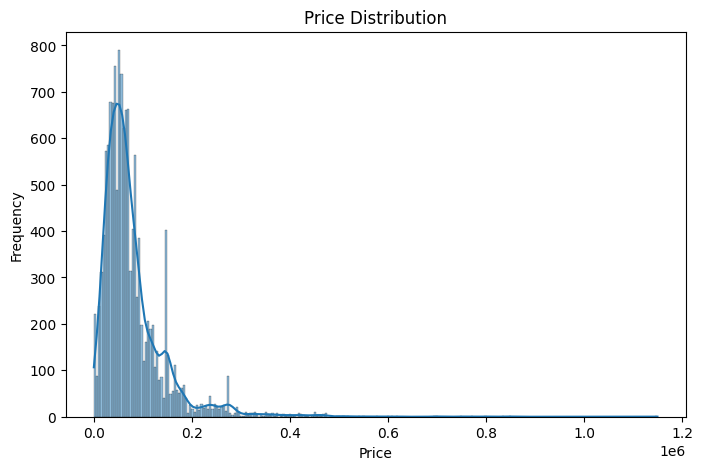


Histogram for: Engine_Size


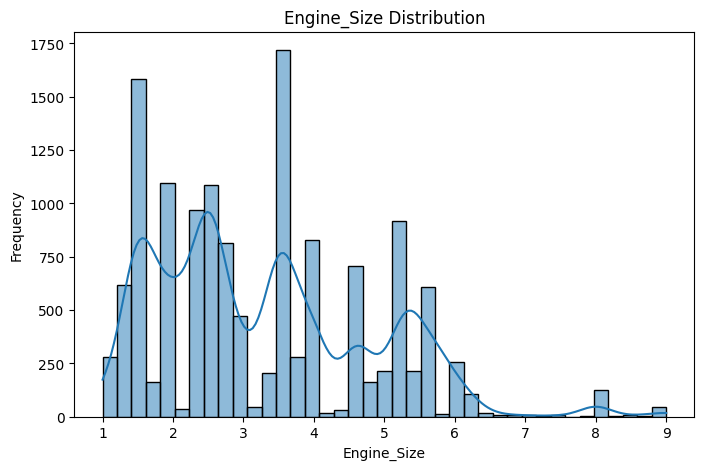


Histogram for: Mileage


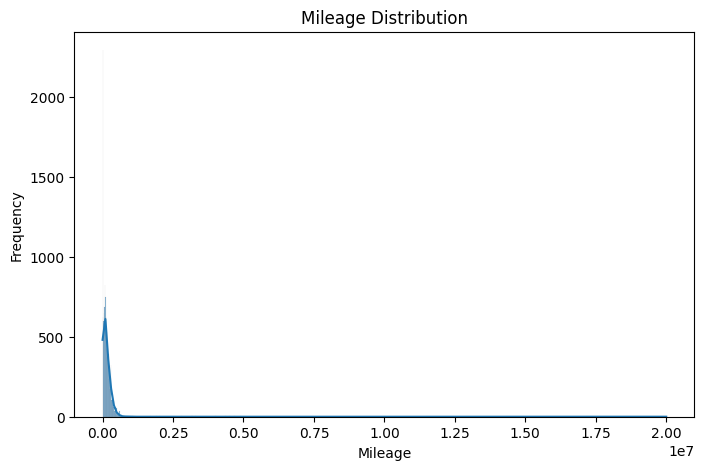


Histogram for: CarAge


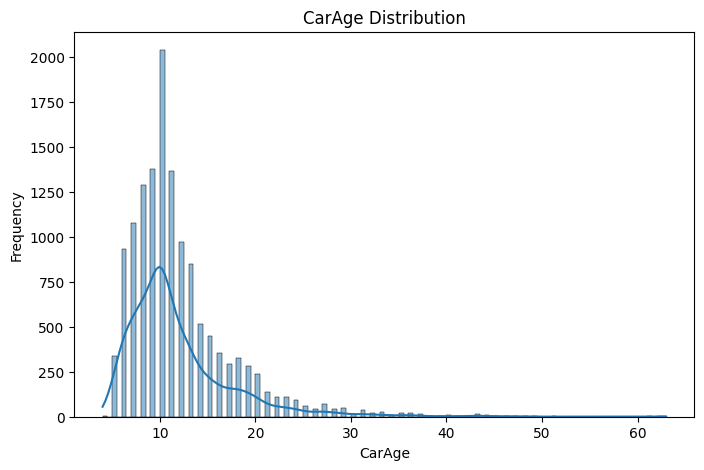


Histogram for: Year


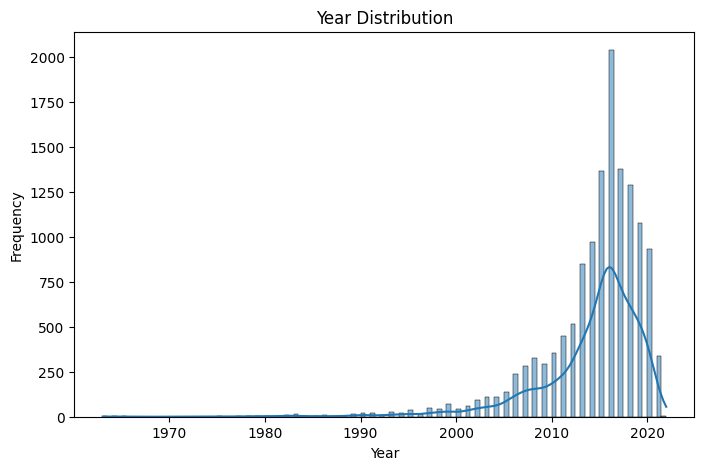

In [4]:

numeric_cols = ['Price', 'Engine_Size', 'Mileage', 'CarAge', 'Year']

for col in numeric_cols:
    print(f"\nHistogram for: {col}")

    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# **Box plot**


---


*   Created boxplots for numeric features.
*   Detected extreme outliers particularly in:


    *   Mileage
    *   Price
    *   CarAge
    *   Engine_Size    


Boxplot for: Price


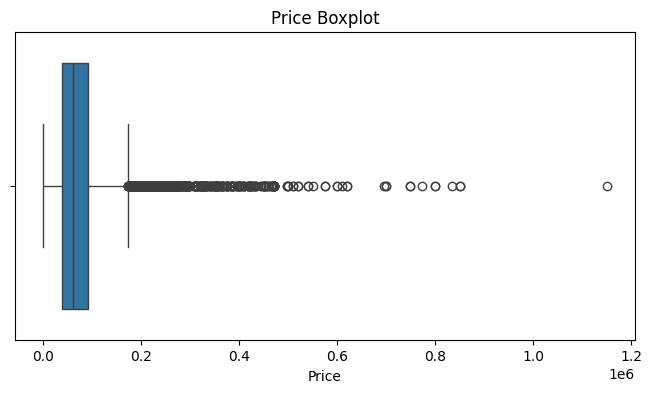


Boxplot for: Engine_Size


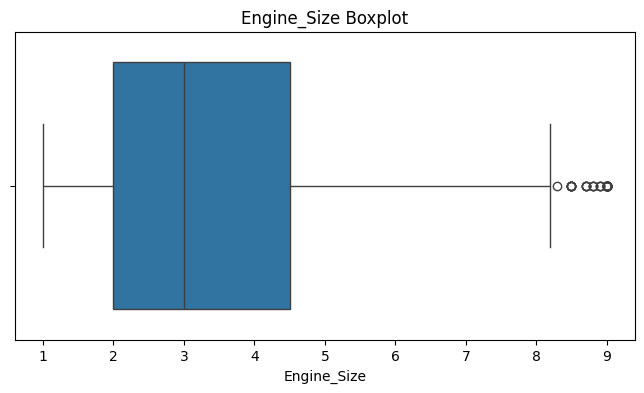


Boxplot for: Mileage


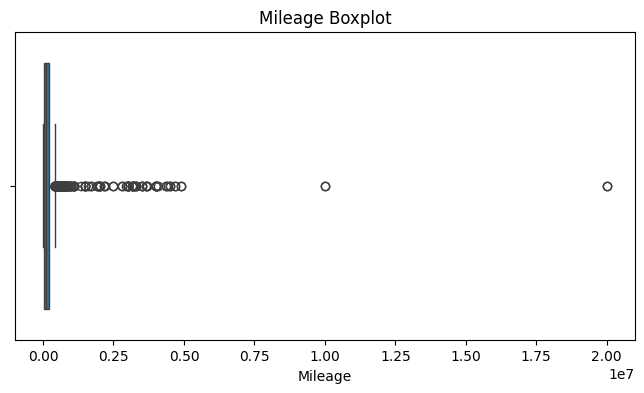


Boxplot for: CarAge


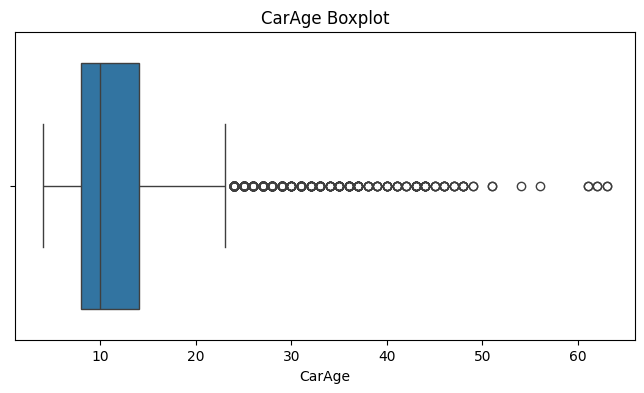


Boxplot for: Year


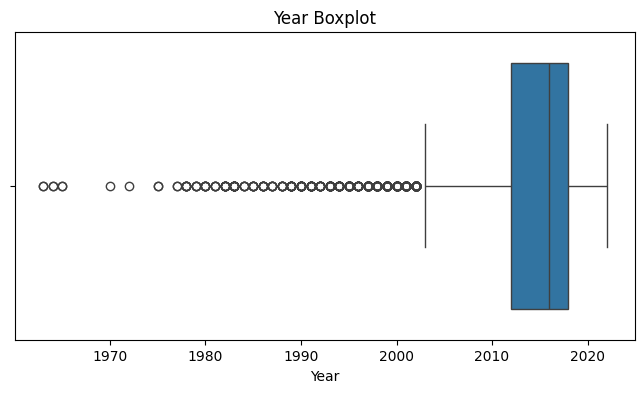

In [5]:
for col in numeric_cols:
    print(f"\nBoxplot for: {col}")

    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.xlabel(col)
    plt.show()

# **Fixing Outliers**

**IQR Method for Mileage**


---

Applied Interquartile Range (IQR) method to remove extreme mileage values.

Calculated:


*   Q1 (25th percentile)

*   Q3 (75th percentile)
*   IQR = Q3 − Q1


*   Removed observations outside:

    > [Q1−1.5IQR,  Q3+1.5IQR] [Q1−1.5IQR,Q3+1.5IQR]





Boxplot for: Mileage


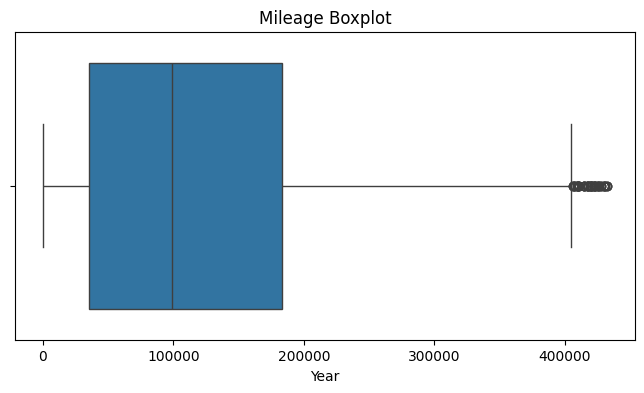

In [6]:
Q1 = df['Mileage'].quantile(0.25)
Q3 = df['Mileage'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Mileage'] >= lower_bound) & (df['Mileage'] <= upper_bound)]
print("\nBoxplot for: Mileage")
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Mileage'])
plt.title("Mileage Boxplot")
plt.xlabel(col)
plt.show()

**Price**


---


Due to right-skewness in the price distribution, a log transformation was applied. The transformed distribution showed improved symmetry and reduced variance, making it more suitable for linear regression modeling.


Actions taken:

- Removed unrealistic values below 10,000 SAR
- Applied logarithmic transformation using

This transformation:

- Reduces skewness
- Stabilizes variance
- Improves suitability for linear regression

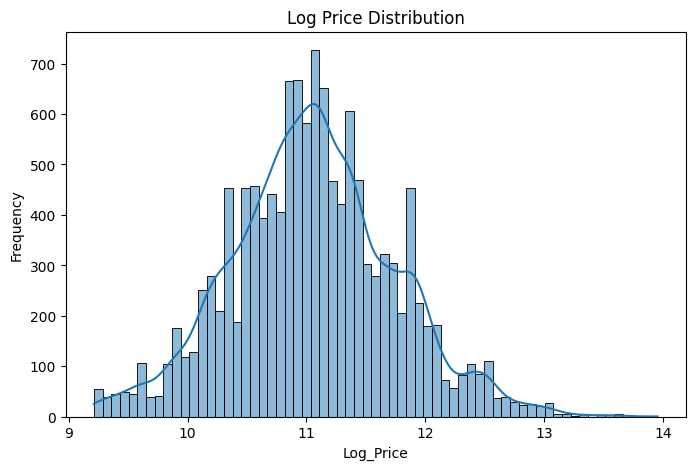

In [7]:
df = df[df['Price'] >= 10000]
df['Price'] = np.log(df['Price'])


plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title("Log Price Distribution")
plt.xlabel("Log_Price")
plt.ylabel("Frequency")
plt.show()

# **Correlation Heatmap**


---

A correlation heatmap was generated for numeric variables.

Key finding:

- Year and CarAge showed perfect negative correlation (-1.00)

Since:

- CarAge = CurrentYear − Year, both variables contain identical information. To avoid multicollinearity, one variable was removed before modeling.

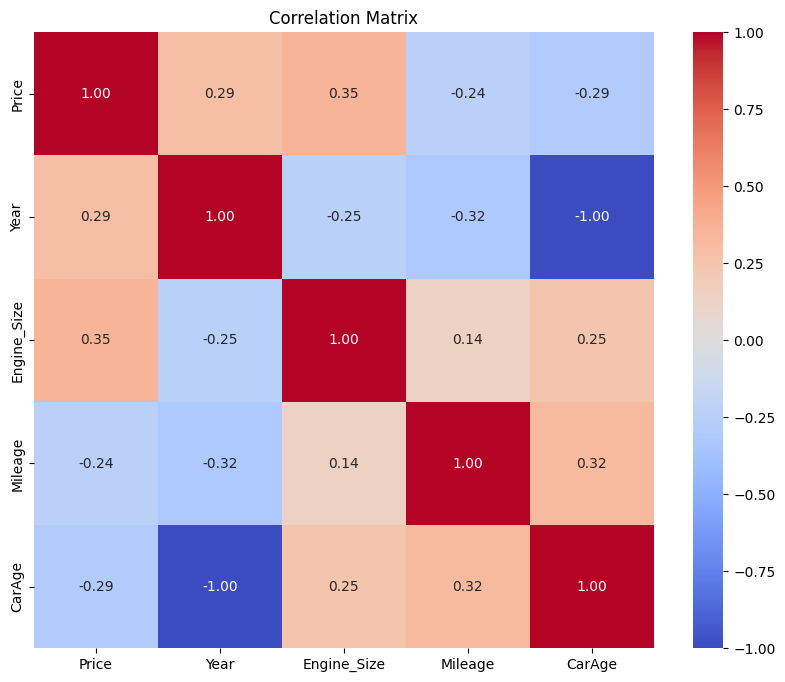

In [8]:
plt.figure(figsize=(10,8))
numeric_cols = ['Price','Year','Engine_Size','Mileage','CarAge']

sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

# Drop the year
df = df.drop(columns=['Year'])

In [9]:
print(df.head(5))

           Make      Type      Price  Region  Gear_Type Origin    Options  \
1         Škoda    Superb   9.615805  Riyadh          0  Other  Semi Full   
2         Škoda    Superb   9.615805  Riyadh          1  Other  Semi Full   
3  Aston Martin       DB9  12.100712  Dammam          0  Saudi       Full   
4  Aston Martin       DB9  12.100712  Dammam          1  Saudi       Full   
5  Aston Martin  Vanquish  12.899220  Dammam          0  Saudi       Full   

   Engine_Size  Mileage  Negotiable  CarAge  
1          1.8   200000           0      18  
2          1.8   200000           0      18  
3          6.0    71000           0      16  
4          6.0    71000           0      16  
5          6.0    32000           0      13  


# **Categorical Analysis**

---

In this section, we analyze categorical features and examine their relationship with the log-transformed vehicle price.
The categorical variables include:
- Origin
- Options
- Region
- Make
- Type
- Gear_Type
- Negotiable.

This helps us understand how these categories influence vehicle pricing patterns.




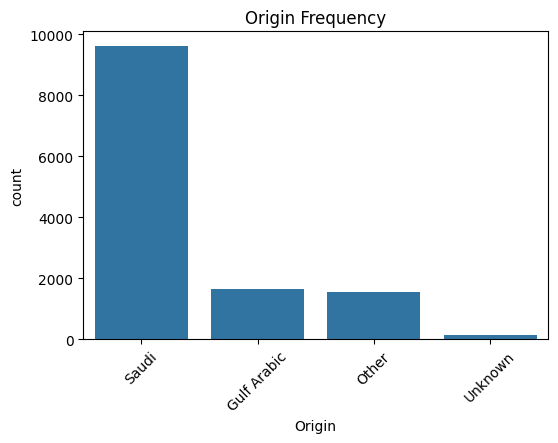

In [10]:
# Categorical Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# 1- Origin Frequency
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Origin', order=df['Origin'].value_counts().index)
plt.title('Origin Frequency')
plt.xticks(rotation=45)
plt.show()



The majority of vehicles in the dataset are of Saudi origin.
Other origins appear in smaller proportions, while Unknown represents a very small portion.

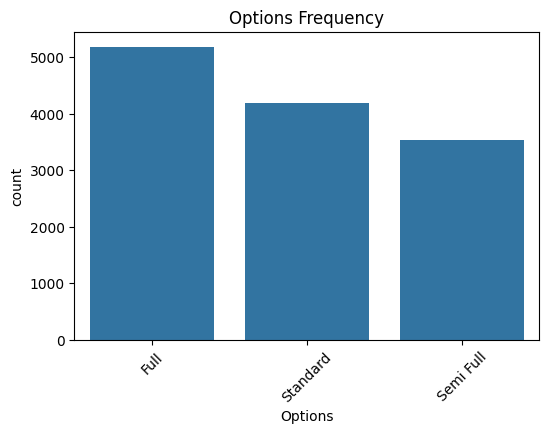

In [11]:
# 2- Options Frequency
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Options', order=df['Options'].value_counts().index)
plt.title('Options Frequency')
plt.xticks(rotation=45)
plt.show()



Full-option vehicles represent the largest portion of the dataset,
followed by Standard and Semi Full categories.

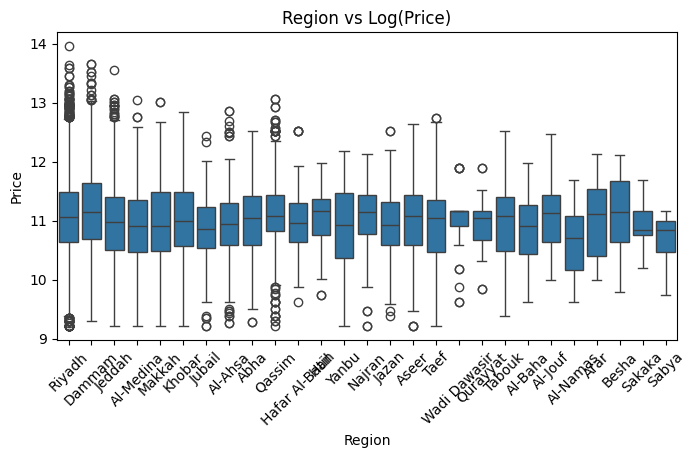

In [12]:
# 3- Region vs Log(Price)
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Region', y='Price')
plt.title('Region vs Log(Price)')
plt.xticks(rotation=45)
plt.show()


There are noticeable variations in vehicle prices across regions.
However, overall price distributions remain relatively consistent.

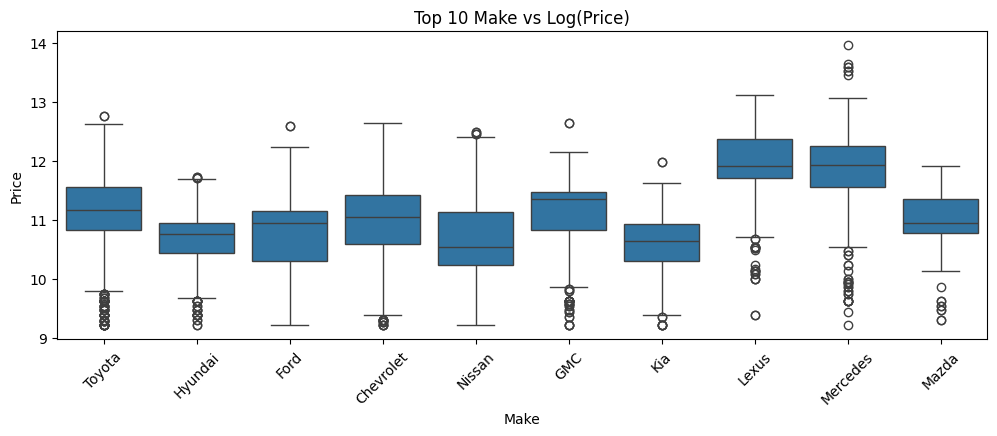

In [13]:
# 4- Top 10 Make vs Log(Price)
top_makes = df['Make'].value_counts().head(10).index

plt.figure(figsize=(12,4))
sns.boxplot(data=df[df['Make'].isin(top_makes)],
            x='Make',
            y='Price',
            order=top_makes)

plt.title('Top 10 Make vs Log(Price)')
plt.xticks(rotation=45)
plt.show()


Correlation: -0.23688305448383154


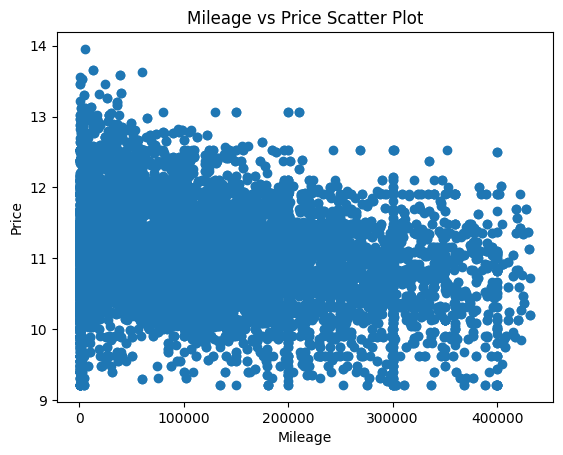

In [14]:
# Create scatter plot
plt.figure()
plt.scatter(df["Mileage"], df["Price"])

plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price Scatter Plot")
correlation = df["Mileage"].corr(df["Price"])
print("Correlation:", correlation)
plt.show()

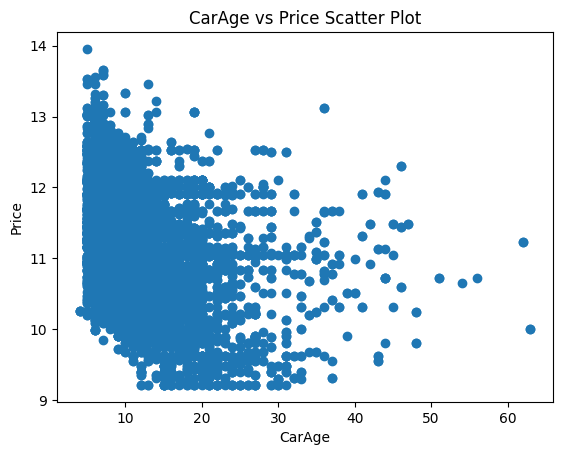

In [15]:
# Create scatter plot
plt.figure()
plt.scatter(df["CarAge"], df["Price"])

plt.xlabel("CarAge")
plt.ylabel("Price")
plt.title("CarAge vs Price Scatter Plot")
plt.show()

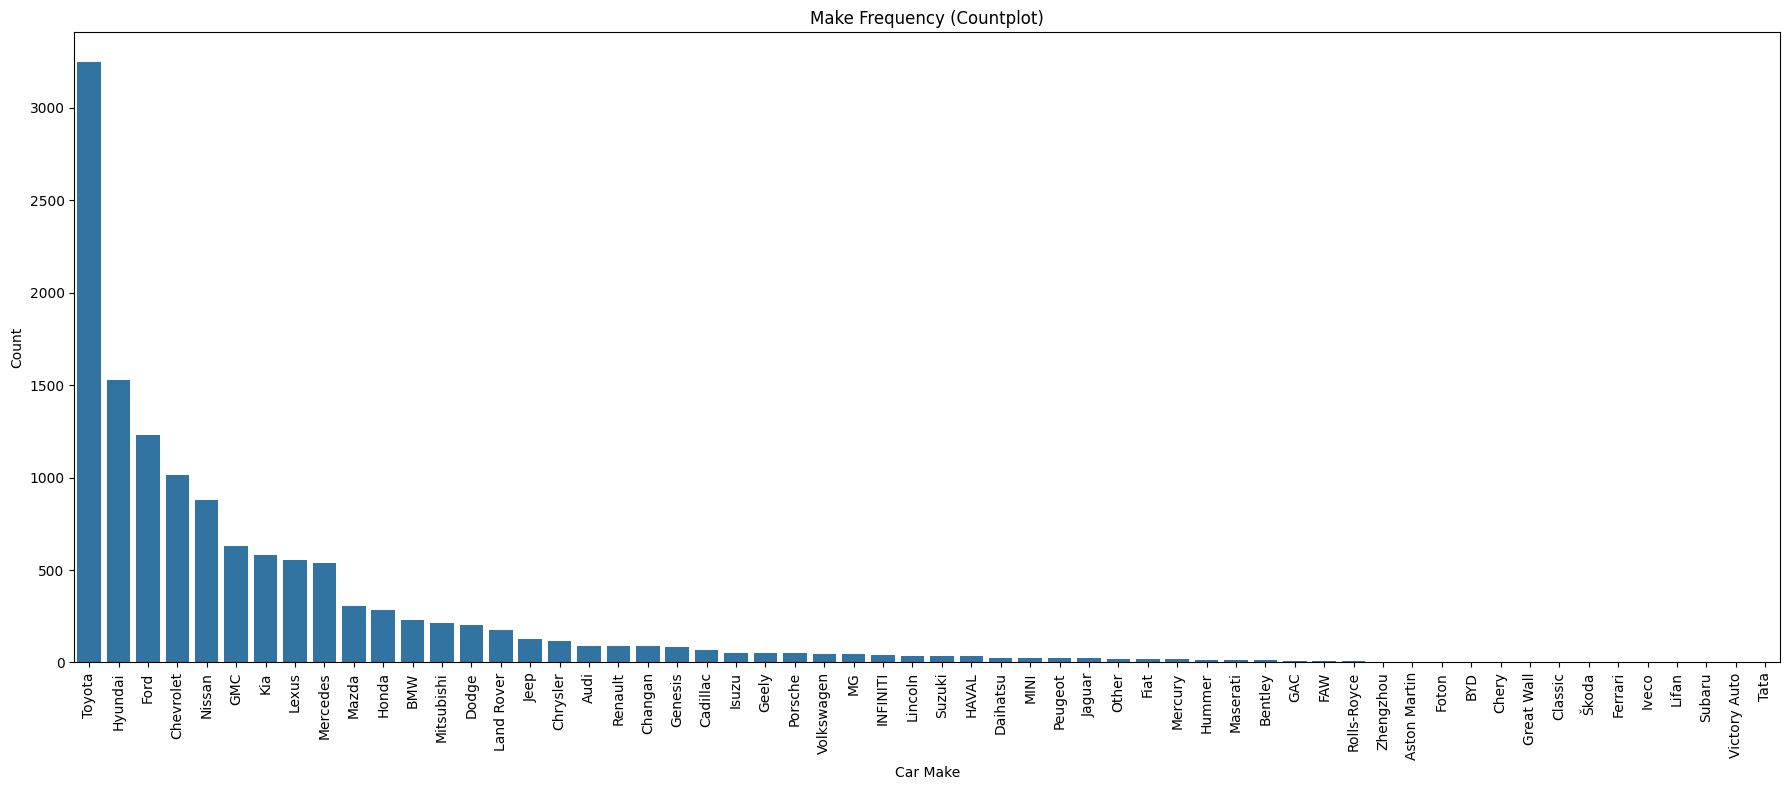

In [16]:
plt.figure(figsize=(18,8))
sns.countplot(data=df, x='Make', order=df['Make'].value_counts().index)

plt.xticks(rotation=90)
plt.title('Make Frequency (Countplot)')
plt.xlabel('Car Make')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

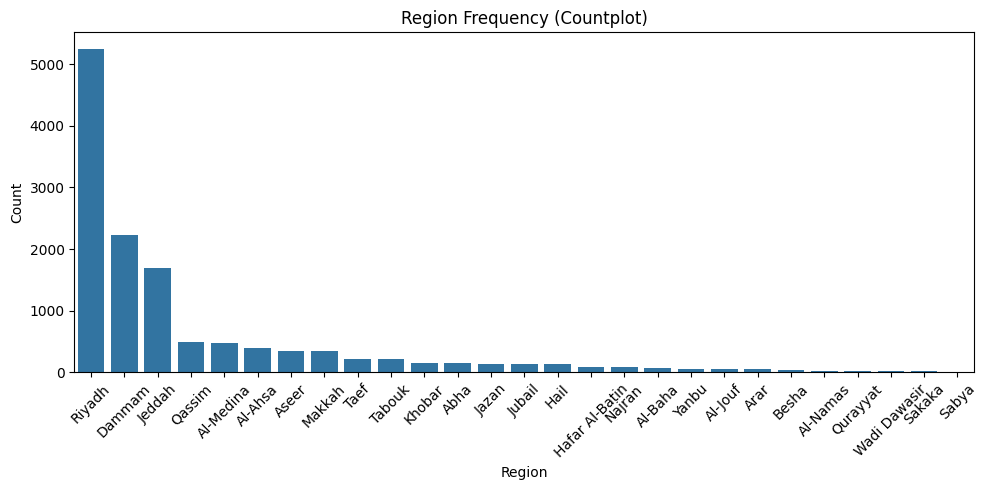

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Region', order=df['Region'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Region Frequency (Countplot)')
plt.xlabel('Region')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Clear differences in median prices are observed across brands.
Luxury brands such as Lexus and Mercedes show higher median prices,
while brands like Hyundai and Kia tend to have lower median prices.

In [19]:
# Export to CSV
df.to_csv("Final_processed_dataset.csv", index=False)